# Matplotlib Formatting Charts

In [5]:
# importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
df_skill_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skill_count = df_skill_count.reset_index(name='skill_count')
df_skill_count = df_skill_count.sort_values(by='skill_count', ascending=False)

In [8]:
df_skill_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [14]:
job_types = ['Data Analyst','Data Engineer','Data Scientist']

In [19]:
list(enumerate(job_types, start=1))

[(1, 'Data Analyst'), (2, 'Data Engineer'), (3, 'Data Scientist')]

In [20]:
for i, job_type in enumerate(job_types):
    print(i, job_type)

0 Data Analyst
1 Data Engineer
2 Data Scientist


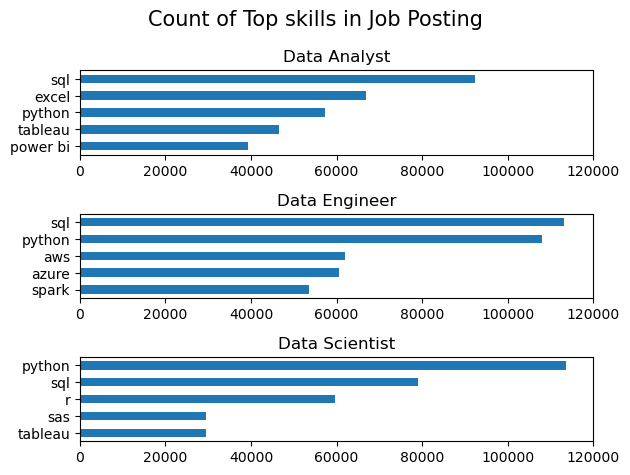

In [44]:
fig, ax = plt.subplots(3,1)

for i, job_type in enumerate(job_types):
    df_skill_plot = df_skill_count[df_skill_count['job_title_short'] == job_type].head()
    df_skill_plot.plot(kind='barh', y= 'skill_count', x='job_skills', ax = ax[i], title=job_type)
    ax[i].invert_yaxis()
    ax[i].legend().set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 120000)

fig.suptitle('Count of Top skills in Job Posting', fontsize = 15)
fig.tight_layout()